In [1]:
!pip install langchain

In [2]:
!pip install transformers
!pip install sentence-transformers
!pip install scikit-learn
!pip install pandas
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 60.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

from sklearn.ensemble import IsolationForest

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

In [4]:
users = {
    "employee": [
        "John",
        "Sarah",
        "Mike",
        "David",
        "Emma",
        "Alex"
    ],

    "role": [
        "Employee",
        "Admin",
        "Intern",
        "Manager",
        "Developer",
        "Contractor"
    ],

    "failed_logins": [
        2,
        18,
        1,
        7,
        3,
        15
    ],

    "sensitive_access": [
        False,
        True,
        False,
        True,
        True,
        False
    ],

    "vpn_access": [
        True,
        True,
        False,
        True,
        True,
        False
    ],

    "location_risk": [
        "LOW",
        "HIGH",
        "LOW",
        "MEDIUM",
        "LOW",
        "HIGH"
    ]
}

df = pd.DataFrame(users)

df

,employee,role,failed_logins,sensitive_access,vpn_access,location_risk
0,John,Employee,2,False,True,LOW
1,Sarah,Admin,18,True,True,HIGH
2,Mike,Intern,1,False,False,LOW
3,David,Manager,7,True,True,MEDIUM
4,Emma,Developer,3,True,True,LOW
5,Alex,Contractor,15,False,False,HIGH


In [5]:
def calculate_risk(row):

    risk_score = 0

    if row['failed_logins'] > 10:
        risk_score += 40

    if row['sensitive_access']:
        risk_score += 30

    if row['location_risk'] == "HIGH":
        risk_score += 20

    if row['role'] == "Admin":
        risk_score += 30

    if risk_score >= 70:
        return "HIGH"

    elif risk_score >= 40:
        return "MEDIUM"

    else:
        return "LOW"

df['risk_level'] = df.apply(
    calculate_risk,
    axis=1
)

df

,employee,role,failed_logins,sensitive_access,vpn_access,location_risk,risk_level
0,John,Employee,2,False,True,LOW,LOW
1,Sarah,Admin,18,True,True,HIGH,HIGH
2,Mike,Intern,1,False,False,LOW,LOW
3,David,Manager,7,True,True,MEDIUM,LOW
4,Emma,Developer,3,True,True,LOW,LOW
5,Alex,Contractor,15,False,False,HIGH,MEDIUM


In [6]:
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [10]:
def ai_security_review(user_data):

    user_text = f"""
Employee Name: {user_data['employee']}
Role: {user_data['role']}
Failed Logins: {user_data['failed_logins']}
Sensitive Access: {user_data['sensitive_access']}
VPN Access: {user_data['vpn_access']}
Location Risk: {user_data['location_risk']}
Risk Level: {user_data['risk_level']}
"""

    prompt = f"""
You are a cybersecurity IAM analyst.

Analyze the following employee access profile.

{user_text}

Provide the response EXACTLY in this format:

Risk Explanation:
<explain the security risk>

Security Concern:
<main concern>

Recommended Action:
<recommended remediation>
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.3,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

In [11]:
sample_user = df.iloc[1]

result = ai_security_review(sample_user)

print(result)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sarah's password was changed to True VPN.


In [12]:
df['ai_review'] = df.astype(str).apply(
    ai_security_review,
    axis=1
)

df

,employee,role,failed_logins,sensitive_access,vpn_access,location_risk,risk_level,ai_review
0,John,Employee,2,False,True,LOW,LOW,John's password is incorrect.
1,Sarah,Admin,18,True,True,HIGH,HIGH,Sarah's password was changed to True VPN.
2,Mike,Intern,1,False,False,LOW,LOW,Mike's login profile is a false one.
3,David,Manager,7,True,True,MEDIUM,LOW,David's password is incorrect.
4,Emma,Developer,3,True,True,LOW,LOW,Emma's password is incorrect.
5,Alex,Contractor,15,False,False,HIGH,MEDIUM,Alex's password is False.


In [13]:
features = df[['failed_logins']]

model_if = IsolationForest(
    contamination=0.2
)

df['anomaly'] = model_if.fit_predict(features)

df

,employee,role,failed_logins,sensitive_access,vpn_access,location_risk,risk_level,ai_review,anomaly
0,John,Employee,2,False,True,LOW,LOW,John's password is incorrect.,1
1,Sarah,Admin,18,True,True,HIGH,HIGH,Sarah's password was changed to True VPN.,-1
2,Mike,Intern,1,False,False,LOW,LOW,Mike's login profile is a false one.,1
3,David,Manager,7,True,True,MEDIUM,LOW,David's password is incorrect.,1
4,Emma,Developer,3,True,True,LOW,LOW,Emma's password is incorrect.,1
5,Alex,Contractor,15,False,False,HIGH,MEDIUM,Alex's password is False.,1


In [14]:
embedding_model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

documents = df.astype(str).values.tolist()

documents = [
    " ".join(doc)
    for doc in documents
]

embeddings = embedding_model.encode(
    documents
)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(6, 384)


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def search_similar_users(query):

    query_embedding = embedding_model.encode([query])

    similarity = cosine_similarity(
        query_embedding,
        embeddings
    )

    index = similarity.argmax()

    return df.iloc[index]

search_similar_users(
    "admin with risky login behavior"
)

,1
employee,Sarah
role,Admin
failed_logins,18
sensitive_access,True
vpn_access,True
location_risk,HIGH
risk_level,HIGH
ai_review,Sarah's password was changed to True VPN.
anomaly,-1


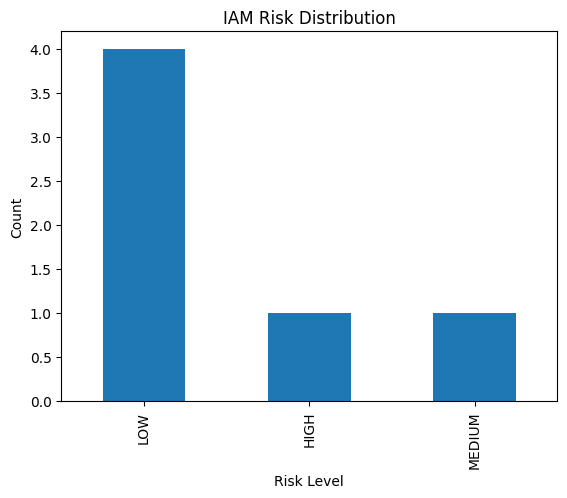

In [16]:
df['risk_level'].value_counts().plot(
    kind='bar'
)

plt.title("IAM Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Count")

plt.show()

In [17]:
import streamlit as st
import pandas as pd

st.title("AI IAM Governance Copilot")

st.write(df)

employee = st.selectbox(
    "Select Employee",
    df['employee']
)

selected = df[
    df['employee'] == employee
]

st.write(selected)

st.write(
    selected['ai_review'].values[0]
)

2026-05-18 08:41:56.223 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 08:41:56.487 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-18 08:41:56.489 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 08:41:56.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 08:41:56.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 08:41:56.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 08:41:56.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 08:41:56.512 Thread 'MainThread': mi